In [1]:
import pandas as pd
df = pd.read_csv("../data/q1_heart_disease.csv")

# 1. Data Loading and Inspection


Show the first five rows.

In [2]:
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


Display the shape of the data

In [3]:
df.shape

(800, 12)

Display the data types of headers inside the csv file

In [4]:
df.dtypes

age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing value counts

In [5]:
df.isnull().sum()

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

# 2. Exploratory Data Analysis 
 
 import the necessary libraries

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

Target Class Distribution plot

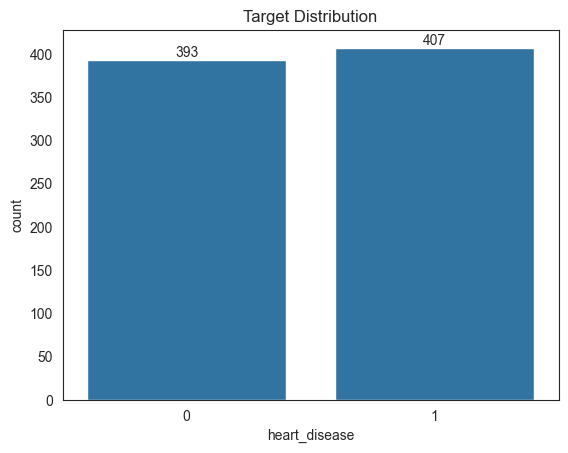

In [7]:
sns.set_style("white")

ax = sns.countplot(x='heart_disease', data=df)

ax.bar_label(ax.containers[0])

plt.title("Target Distribution")
plt.show()

From the plot we can see an even distribution of target variable between classes 0 and 1 indicating that the data is balanced.

Correlation Heatmap

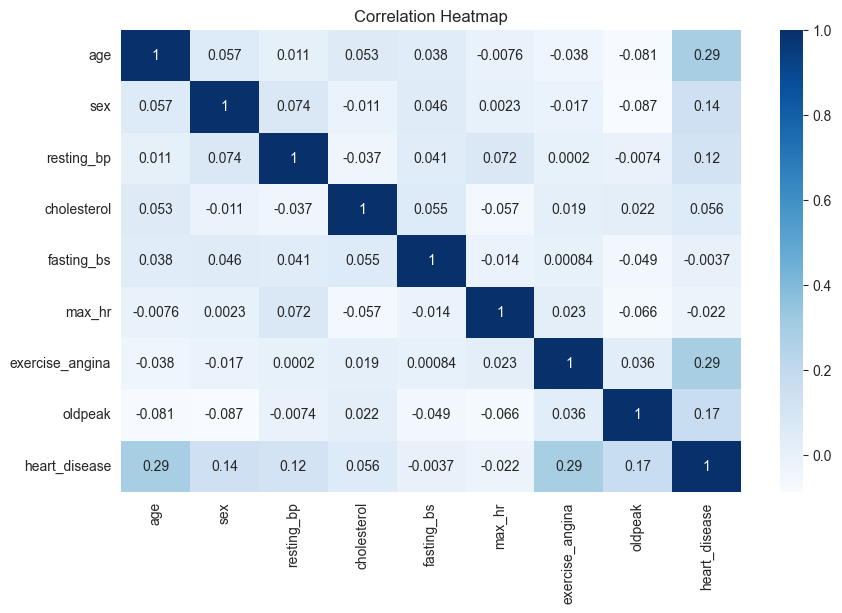

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows the relationship between numerical features. It helps to identify the correlation of features with the target variable and among themselves.


Feature vs Target

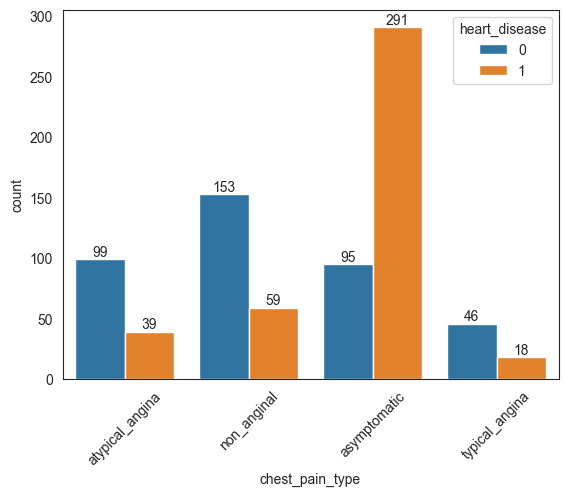

In [9]:
ax = sns.countplot(x='chest_pain_type', hue='heart_disease', data=df)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.xticks(rotation=45)
plt.show()

All chest pain categories have both patients with and without heart disease. However, the asymptomatic category shows a higher number of patients with heart disease, indicating a stronger association. This suggests that chest pain type is useful but not sufficient alone for prediction.

# 3. Data Preprocessing 

Handling Missing Values

In [10]:
bins = [30, 40, 50, 60, 70, 80]
labels = ['30-40','41-50','51-60','61-70','71-80']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)
group_median = df.groupby(['age_group', 'sex', 'heart_disease'])['resting_bp'].transform('median')
df['resting_bp'] = df['resting_bp'].fillna(group_median)
group_median = df.groupby(['age_group', 'heart_disease'])['cholesterol'].transform('median')
df['cholesterol'] = df['cholesterol'].fillna(group_median)

Justification:

Missing values in resting_bp are filled using the median based on age group, sex, and heart disease. This means values are taken from people who are similar in age, gender, and heart disease, making the filling more realistic.

Missing values in cholesterol are filled using the median based on age group and heart disease. This helps in using values from similar patients.

Median is used instead of mean because it is not affected much by outliers, so it gives more stable results.


One-Hot Encoding

In [11]:
df = pd.get_dummies(df, drop_first=True, dtype=int)
df.drop(columns=[col for col in df.columns if 'age_group' in col], inplace=True)

Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x = df.drop('heart_disease', axis=1)
y = df['heart_disease']

x_scaled = scaler.fit_transform(x)


Splitting the Data

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Model Training

# Decision Tree Classifier

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)
y_pred = dt_model.predict(x_test)

# Random Forest Classifier

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)
y_pred_rf = rf_model.predict(x_test)

# Gradient Boosting Classifier

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(x_train, y_train)
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)
y_pred_gb = gb_model.predict(x_test)

# 5. Model Evaluation

# Decision Tree Classifier 

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

confusion_matrix(y_test, y_pred)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56 23]
 [25 56]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160



# Random Forest Classifier

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[59 20]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        79
           1       0.77      0.81      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160



# Gradient Boosting Classifier

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

[[58 21]
 [17 64]]
              precision    recall  f1-score   support

           0       0.77      0.73      0.75        79
           1       0.75      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160



Justification:


 Random Forest has the highest accuracy (0.78) and also gives better precision, recall, and F1-score compared to Decision Tree and Gradient Boosting. Most importantly, it achieves the highest recall (0.81) for heart disease, which means it can correctly identify more patients with heart disease. It also has the lowest number of false negatives (15), so fewer actual patients are missed. This is very important in medical cases where missing a patient can be dangerous.

Overall, Random Forest provides the best balance across all evaluation metrics and is the most reliable model for this problem.

# 6. Hyperparameter Tuning 

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report


rf = RandomForestClassifier(random_state=42)


param_grid = {
    
    'class_weight': ['balanced'],
    
    'min_samples_leaf': [1, 2]
}


grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)


grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)


best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(x_test)


print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'class_weight': 'balanced', 'min_samples_leaf': 1}
[[60 19]
 [14 67]]
              precision    recall  f1-score   support

           0       0.81      0.76      0.78        79
           1       0.78      0.83      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



Hyperparameter Tuning Results and Comparison

The best parameters found using GridSearchCV were:
class_weight = 'balanced' and min_samples_leaf = 1

After tuning, the model showed slight improvement compared to the untuned Random Forest.

The recall for heart disease increased from 0.81 to 0.83, which means the tuned model is able to identify more patients correctly. The number of false negatives also reduced from 15 to 14, meaning fewer actual patients are missed. In addition, the overall accuracy improved from 0.78 to 0.79, and the F1-score also increased slightly.

Overall, the tuned model performs better than the baseline, especially in terms of recall, which is the most important metric for this problem.